In [11]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

from itertools import product
import os
import h5py
from tqdm import tqdm
import pandas as pd

#few utils
from few.utils.utility import get_p_at_t
from few.utils.constants import MTSUN_SI
from few.utils.geodesic import get_fundamental_frequencies
#few trajectory
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import SuperKludgeFlux
#few waveform
from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform
from few.utils.constants import YRSID_SI

#sef imports
from stableemrifisher.fisher import StableEMRIFisher
from stableemrifisher.utils import generate_PSD, padding, inner_product
from stableemrifisher.fisher.derivatives import derivative
from stableemrifisher.fisher.stablederivative import StableEMRIDerivative
from stableemrifisher.noise import sensitivity_LWA

#lisa-on-gpu import
from fastlisaresponse import ResponseWrapper  # Response function 

#LISAanalysistools imports
from lisatools.detector import ESAOrbits, EqualArmlengthOrbits #ESAOrbits correspond to esa-trailing-orbits.h5, EqualArmlengthOrbits are equalarmlength-orbits.h5
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from lisatools.sensitivity import get_sensitivity,CornishLISASens

use_gpu = True #False if your computer sucks (mine does)

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");
else:
    pass #let the backend decide for itself

In [12]:
#waveform class setup
waveform_class = SuperKludgeWaveform
max_step_days = 10.0 #max trajectory step size in days
inspiral_kwargs = {
    "err":1e-11, #default = 1e-11
    "max_step_size":max_step_days*24*60*60, #in seconds
}
sum_kwargs = {
    "pad_output": True, # True if expecting waveforms smaller than LISA observation window.
}

waveform_class_kwargs = dict(inspiral_kwargs=inspiral_kwargs,
                              mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                              sum_kwargs=sum_kwargs,
                              use_gpu=use_gpu)

waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(return_list=False)


In [ ]:
if(use_gpu):
    xp=cp
else:
    xp=np

m1 = 1e6
m2 = 10
a = 0.85 # 0.95
e0 = 0.45 # 0.6 just spin first
xI0 = 1.0
dist = 0.4
qS = xp.pi/4
phiS = 1.0
qK = 1 
phiK = xp.pi/3
Phi_phi0 = 0.9
Phi_theta0 =0.5
Phi_r0 = 0.4

dt = 10.0
T = 0.5

chi2 = 0.0

dev_0_p=0.0
dev_0_e=0.0
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0 
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=True
p0=7.0

print(use_gpu)

True


In [14]:
SK_traj = EMRIInspiral(func=SuperKludgeFlux,use_gpu=use_gpu)
add_args= [chi2, evolve_1PA, evolve_primary, evolve_2PA,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
p0_ = get_p_at_t(traj_module=SK_traj, t_out=T, traj_args=[m1, m2, a, e0, xI0, *add_args])
print(p0_)

6.15520119371335


In [15]:
filename= "rishav_CVBias"

add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

# with longer signals we care less about this
t0 = 10000.0  # throw away on both ends when our orbital information is weird

In [16]:
pars_list_com = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
             chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

print(use_gpu)
der_order = 8
Ndelta=8
sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                       channels=["A","E"],
                       T = T, dt = dt,
                       stability_plot = True,
                       der_order = der_order, Ndelta = Ndelta,
                       plunge_check=True, return_derivatives=True
                       )
                   

der_order = 12
Ndelta = 8
stability_plot = True

param_names_com = ['m1','m2','a','p0','e0','xI0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_theta0','Phi_r0',"chi2",
               "evolve_1PA","evolve_primary","evolve_2PA","deviation_included","dev0p","dev0e","dev1p","dev1e","dev2p","dev2e"]

param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']
emri_kwargs = {"T":T, "dt":dt}
# sef.waveform_generator.backend.uses_cupy

True


In [17]:

SNR = sef.SNRcalc_SEF(*pars_list_com,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

waveform shape:  (2, 1577908)
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10, 0.85, 7.0, 0.45, 1.0, 0.4, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.9, 0.5, 0.4, 0.0, False, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
SNR:  85.19817367978543


In [18]:
# got from Shubham's code
def cutlervallis(waveform_truth, waveform_approx, Fisher_truth, partial_approx, params_truth, PSD_func, dt, use_gpu=False):
    """
    Calculate best-fit param points using the Cutler-Vallisneri linear-bias approximation.
    params:
        waveform_truth (ndarray) : the time-series waveform from the true template at params_truth. ndarray of shape 'N x M' where N is number of LISA channels and M is the time-series length
        waveform_approx (ndarray) : the time-series waveform from the approximate template at params_truth. ndarray of shape 'N x M' where N is number of LISA channels and M is the time-series length
        partial_approx (ndarray) : the time-series partial derivative of the approximate template at params_truth. ndarray of shape 'N x M' where N is number of LISA channels and M is the time-series length
        Fisher_truth (ndarray) : the Fisher matrix (log-mass units) at params_truth. ndarray of shape 'd x d'
        params_truth (ndarray) : the array of true params. ndarray of shape 'd'
        PSD_func (ndarray) : the frequency-domain LISA noise sensitivity curve. ndarray of shape 'N x L' where L is the length of the frequency series. 

    returns:
        CV_bias (ndarray): params_truth + np.linalg.inv(Fisher_truth) @ inner_product(partial_approx, waveform_truth - waveform_approx)
    """

#Equation 29 of cutler-vallisneri paper
    if use_gpu:
        xp = cp
    else:
        xp = np
        
    #waveform_truth = padding(waveform_truth, waveform_approx, use_gpu = use_gpu) #make waveform_truth the same length as waveform_approx
    delta_wave = waveform_truth - waveform_approx
    #truth contains 1 order PN and approx contains 0 order PN with deviations

    # calculate all the column-wise inner products
    inn_prods = []
    
    for j in range(len(Fisher_truth)):
        
        print("delta_wave.shape, partial_approx.shape: ", delta_wave.shape, partial_approx[j].shape)
                      
        inn_prod_j = inner_product(partial_approx[j], delta_wave, PSD=PSD_func, dt=dt, use_gpu = use_gpu) #should be a scalar
        if not use_gpu:
            inn_prod_j = xp.asarray(inn_prod_j)
        else:
            inn_prod_j = xp.asnumpy(inn_prod_j)
            
        print(f'inner_prod at j = {j}: ', inn_prod_j)
        inn_prods.append(inn_prod_j)
        
    inn_prods = np.array(inn_prods)
    # calculate all the param shifts
    delta_param_all = []
    
    for i in range(len(Fisher_truth)):
            
        delta_param_i = np.linalg.inv(Fisher_truth)[i,:]@inn_prods  #should be a scalars
        print(f"{param_names[i]} have delta {delta_param_i}")
        delta_param_all.append(delta_param_i)
        
    print('delta_param_all: ', delta_param_all)
    return params_truth + np.array(delta_param_all)


Body is not plunging, Fisher should be stable.
waveform shape:  (2, 1577908)
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10, 0.85, 7.0, 0.45, 1.0, 0.4, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.9, 0.5, 0.4, 0.0, False, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
Waveform Generated. SNR: 85.19817367978543
calculating stable deltas...
Gamma_ii for m1: 1058.1151532833221
Gamma_ii for m1: 1058.1151532842991
Gamma_ii for m1: 1058.115153273156
Gamma_ii for m1: 1058.115153312744
Gamma_ii for m1: 1058.1151531732594
Gamma_ii for m1: 1058.1151532309302
Gamma_ii for m1: 1058.1151527120817
Gamma_ii for m1: 1058.1151559538594
Gamma_ii for m1: 1058.1151470178793
Gamma_ii for m1: 1058.1151919257559
Gamma_ii for m1: 1058.1151906828538
Gamma_ii for m1: 1058.1153279481725
[np.float64(9.23363284560255e-13), np.float64(1.0531111903701543e-11), np.float64(3.7413726197455007e-11), np.float64(1.318237003969694e-10), np.float64(5.450336051766141e-11), np.float64(4.903516749926001e-10)

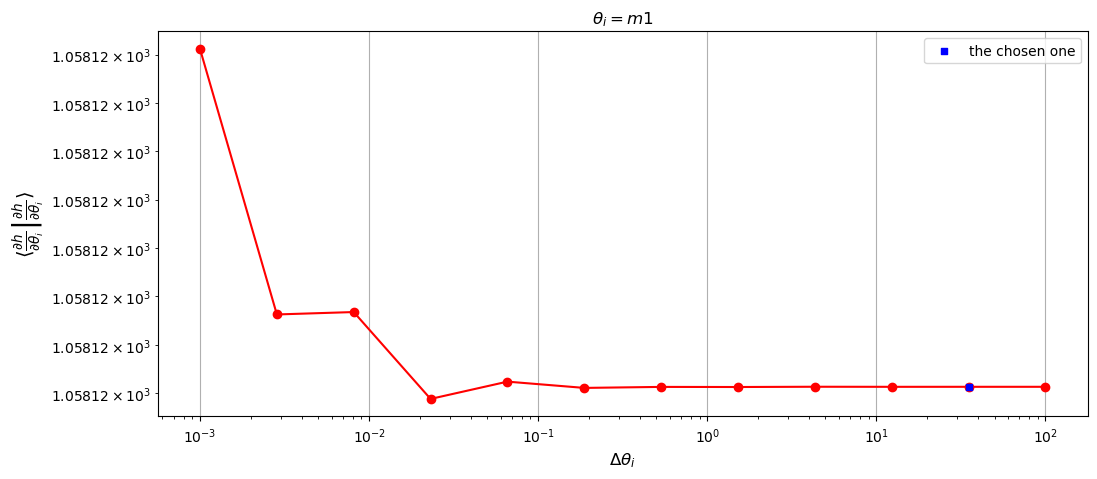

Gamma_ii for m2: 162358931293.5992
Gamma_ii for m2: 162358931286.86758
Gamma_ii for m2: 162358931323.35883
Gamma_ii for m2: 162358931299.75363
Gamma_ii for m2: 162358931638.5278
Gamma_ii for m2: 162358931721.7832
Gamma_ii for m2: 162358931751.5185
Gamma_ii for m2: 162358929921.1912
Gamma_ii for m2: 162358935323.43896
Gamma_ii for m2: 162358933935.19925
Gamma_ii for m2: 162358844388.9545
Gamma_ii for m2: 162359074784.70093
[np.float64(4.146139891790011e-11), np.float64(2.2475660043857456e-10), np.float64(1.4538894720990747e-10), np.float64(2.086575505905114e-09), np.float64(5.127860889969012e-10), np.float64(1.831453940141217e-10), np.float64(1.127333927313902e-08), np.float64(3.327348606625718e-08), np.float64(8.550436258285894e-09), np.float64(5.515329028608713e-07), np.float64(1.4190506242719333e-06)]
0


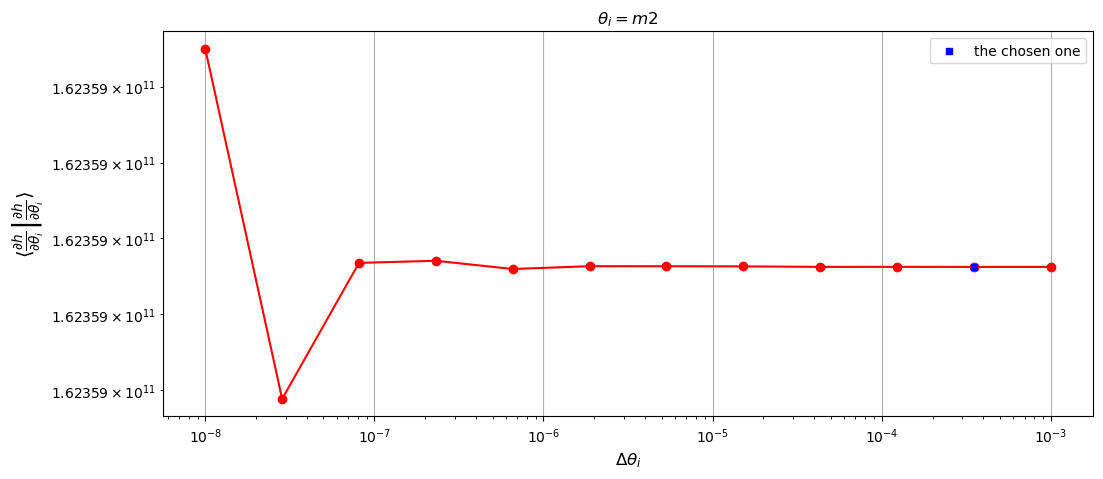

Gamma_ii for a: 13570160749973.178
Gamma_ii for a: 13570167098093.479
Gamma_ii for a: 13570151435258.705
Gamma_ii for a: 13570167253040.965
Gamma_ii for a: 13570154345107.219
Gamma_ii for a: 13570212184408.139
Gamma_ii for a: 13570707041260.836
Gamma_ii for a: 13570093911896.11
Gamma_ii for a: 13570713403182.568
Gamma_ii for a: 13560153662849.307
Gamma_ii for a: 13558043720153.197
Gamma_ii for a: 13673642284967.871
[np.float64(4.677997149845797e-07), np.float64(1.1542122317619441e-06), np.float64(1.1656291307847357e-06), np.float64(9.512002161381285e-07), np.float64(4.262225242607326e-06), np.float64(3.646507519414325e-05), np.float64(4.5182396577894556e-05), np.float64(4.564913192505435e-05), np.float64(0.0007787330878257075), np.float64(0.0001556229452906303), np.float64(0.008454116496945163)]
0


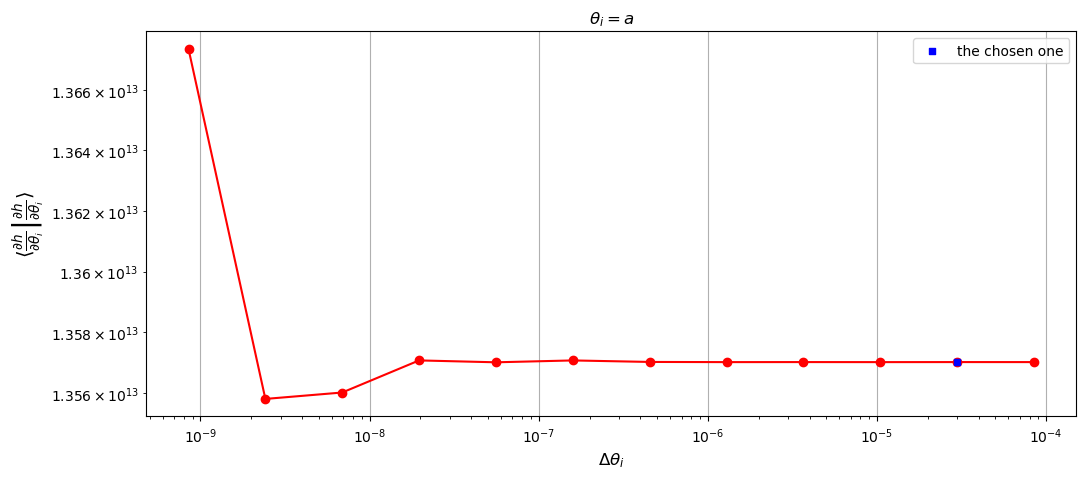

Gamma_ii for p0: 48815772023046.23
Gamma_ii for p0: 48815772978048.6
Gamma_ii for p0: 48815772186759.375
Gamma_ii for p0: 48815761893790.664
Gamma_ii for p0: 48815777763179.5
Gamma_ii for p0: 48815785545479.91
Gamma_ii for p0: 48815888870587.97
Gamma_ii for p0: 48815683308634.055
Gamma_ii for p0: 48817585765039.984
Gamma_ii for p0: 48811925496749.266
Gamma_ii for p0: 48824741634175.516
Gamma_ii for p0: 48815969684343.55
[np.float64(1.956339758113518e-08), np.float64(1.620970418198417e-08), np.float64(2.1085338652159313e-07), np.float64(3.25087288641079e-07), np.float64(1.594218001265085e-07), np.float64(2.116628631641169e-06), np.float64(4.210981798911021e-06), np.float64(3.897071877102338e-05), np.float64(0.00011596076641343943), np.float64(0.00026249268295726476), np.float64(0.000179694265804621)]
1


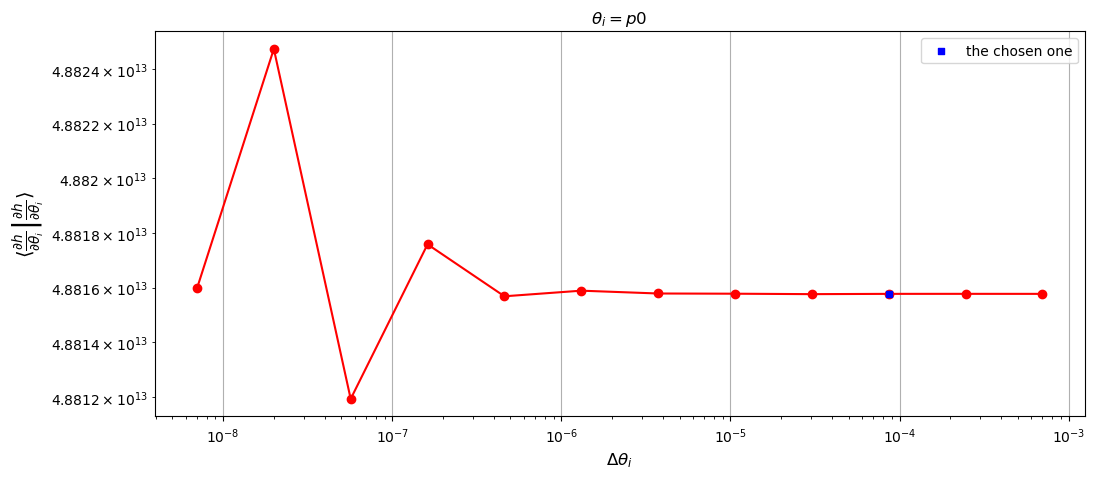

Gamma_ii for e0: 742253144584924.5
Gamma_ii for e0: 742253185970430.6
Gamma_ii for e0: 742253205540493.4
Gamma_ii for e0: 742253405323802.0
Gamma_ii for e0: 742253717735516.0
Gamma_ii for e0: 742253635120890.5
Gamma_ii for e0: 742253446916760.0
Gamma_ii for e0: 742288798674628.9
Gamma_ii for e0: 742232896956195.5
Gamma_ii for e0: 742193309622749.2
Gamma_ii for e0: 742447110903010.6
Gamma_ii for e0: 739446301125474.2
[np.float64(5.5756589405395546e-08), np.float64(2.6365750398813687e-08), np.float64(2.6915782021619176e-07), np.float64(4.208961255904686e-07), np.float64(1.1130241953822779e-07), np.float64(2.5355777232396757e-07), np.float64(4.7625341958542624e-05), np.float64(7.531560331348957e-05), np.float64(5.333830544278541e-05), np.float64(0.0003418442560207232), np.float64(0.004058184851244766)]
1


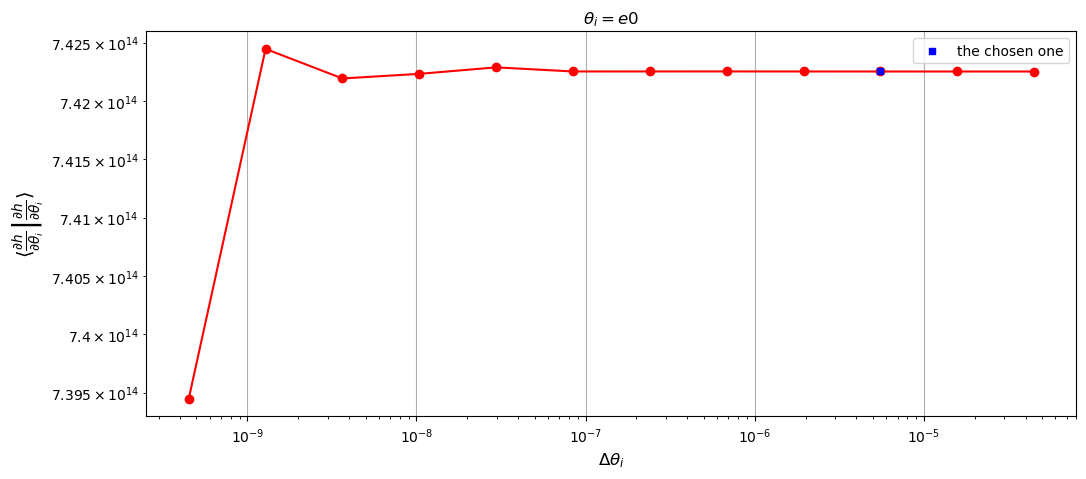

Gamma_ii for qS: 22279.264733025164
Gamma_ii for qS: 22279.264765480646
Gamma_ii for qS: 22279.26476548853
Gamma_ii for qS: 22279.264765488442
Gamma_ii for qS: 22279.26476548771
Gamma_ii for qS: 22279.264765492902
Gamma_ii for qS: 22279.26476548831
Gamma_ii for qS: 22279.264765525175
Gamma_ii for qS: 22279.264765471904
Gamma_ii for qS: 22279.26476585076
Gamma_ii for qS: 22279.26476549074
Gamma_ii for qS: 22279.264766286215
[np.float64(1.456757324958927e-09), np.float64(3.538492027429737e-13), np.float64(3.918957483078635e-15), np.float64(3.282126892078465e-14), np.float64(2.330146803480039e-13), np.float64(2.0607184765188613e-13), np.float64(1.6546165073320975e-12), np.float64(2.3910539343651275e-12), np.float64(1.700484638848704e-11), np.float64(1.61593313117877e-11), np.float64(3.570464188768017e-11)]
2


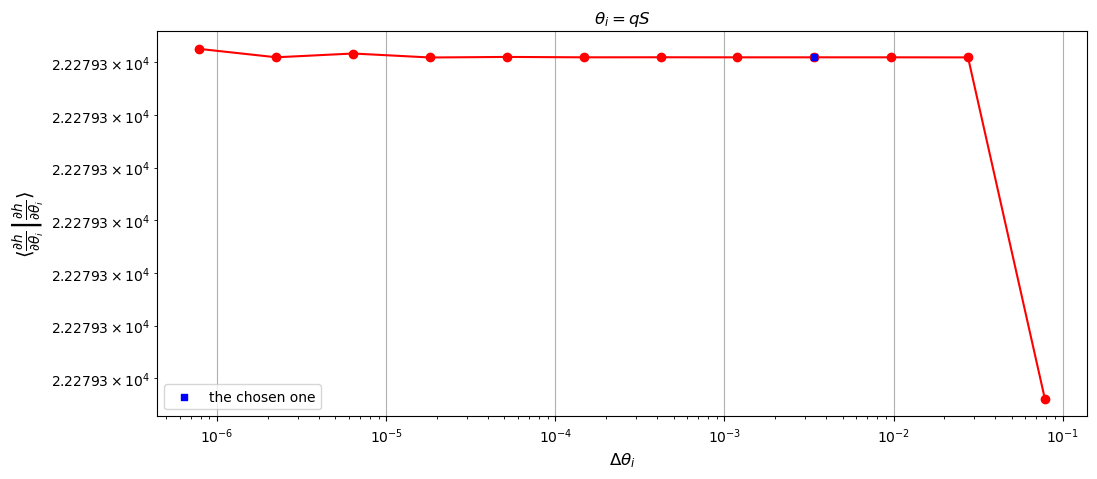

Gamma_ii for phiS: 430159.9929000994
Gamma_ii for phiS: 430159.99289196596
Gamma_ii for phiS: 430159.9928919639
Gamma_ii for phiS: 430159.9928919639
Gamma_ii for phiS: 430159.992891964
Gamma_ii for phiS: 430159.992891964
Gamma_ii for phiS: 430159.99289196386
Gamma_ii for phiS: 430159.99289196456
Gamma_ii for phiS: 430159.9928919649
Gamma_ii for phiS: 430159.99289196375
Gamma_ii for phiS: 430159.99289196334
Gamma_ii for phiS: 430159.99289197405
[np.float64(1.890788265179837e-11), np.float64(4.736070684479079e-15), np.float64(0.0), np.float64(1.353163052708308e-16), np.float64(0.0), np.float64(2.7063261054166167e-16), np.float64(1.6237956632499676e-15), np.float64(8.118978316249831e-16), np.float64(2.7063261054166174e-15), np.float64(9.47214136895817e-16), np.float64(2.4898200169832286e-14)]
2


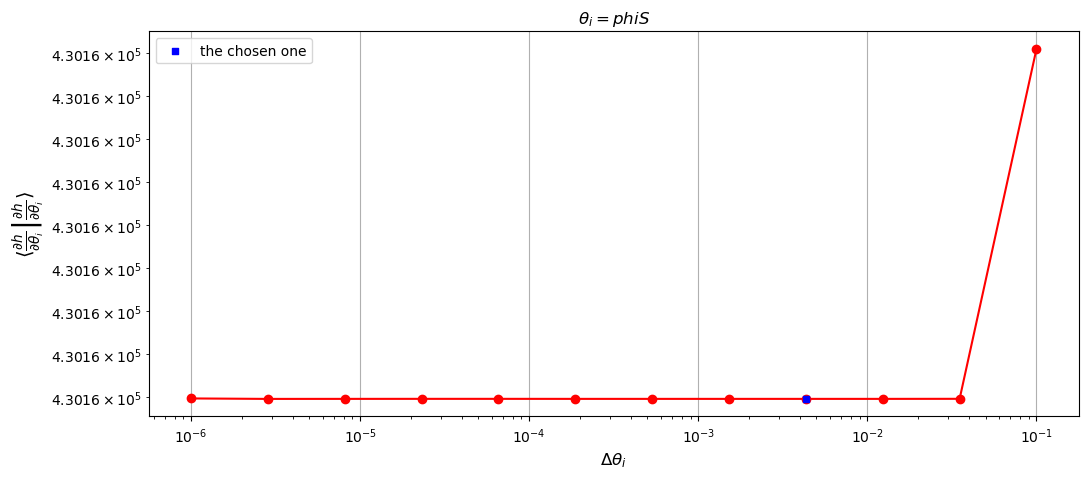

Gamma_ii for dev0p: 8908980942043.34
Gamma_ii for dev0p: 8908978852195.545
Gamma_ii for dev0p: 8908982587088.48
Gamma_ii for dev0p: 8908960142929.297
Gamma_ii for dev0p: 8908918760886.734
Gamma_ii for dev0p: 8908948588584.713
Gamma_ii for dev0p: 8909583671326.52
Gamma_ii for dev0p: 8910226447963.047
Gamma_ii for dev0p: 8913198682490.373
Gamma_ii for dev0p: 8897247605815.672
Gamma_ii for dev0p: 8872794014532.76
Gamma_ii for dev0p: 8760002595668.172
[np.float64(2.3457770296613166e-07), np.float64(4.1922777365843577e-07), np.float64(2.5192793349072087e-06), np.float64(4.645012899228762e-06), np.float64(3.348060400386045e-06), np.float64(7.128085500229498e-05), np.float64(7.213920322690428e-05), np.float64(0.0003334644085927322), np.float64(0.0017928102466514223), np.float64(0.00275601927001343), np.float64(0.012875728931902752)]
0


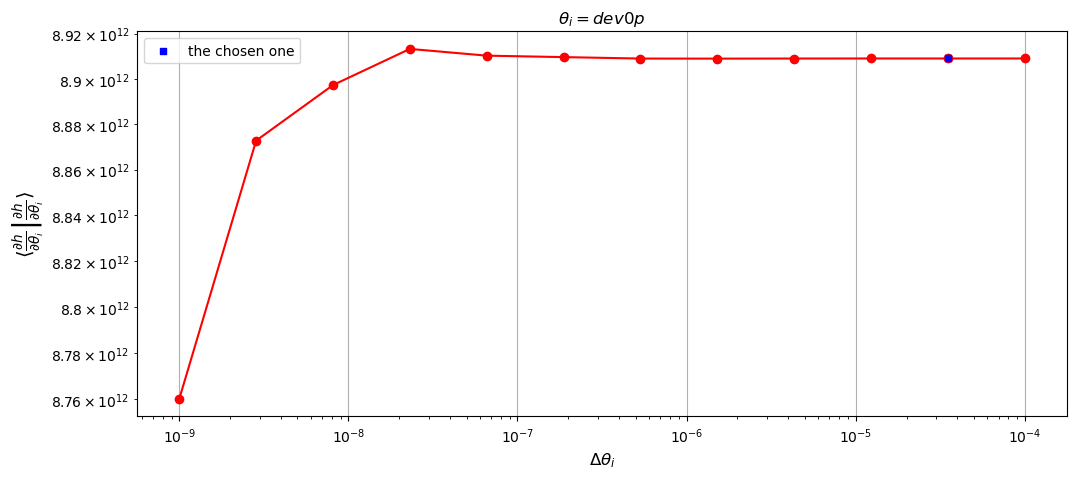

Gamma_ii for dev0e: 1105263433837.2175
Gamma_ii for dev0e: 1105263728037.2227
Gamma_ii for dev0e: 1105267912833.6213
Gamma_ii for dev0e: 1105272071926.661
Gamma_ii for dev0e: 1105278606897.1692
Gamma_ii for dev0e: 1105255603981.9265
Gamma_ii for dev0e: 1105313912232.437
Gamma_ii for dev0e: 1105773625116.947
Gamma_ii for dev0e: 1104725123757.0583
Gamma_ii for dev0e: 1106375611329.8855
Gamma_ii for dev0e: 1097308343131.5591
Gamma_ii for dev0e: 1134334633507.0205
[np.float64(2.6618081971205806e-07), np.float64(3.7862280720272643e-06), np.float64(3.762958591997024e-06), np.float64(5.912509721550025e-06), np.float64(2.0812303651574096e-05), np.float64(5.275266136181264e-05), np.float64(0.00041573869557739757), np.float64(0.0009491061055286087), np.float64(0.0014917967785309633), np.float64(0.008263190793254835), np.float64(0.032641417516264405)]
0


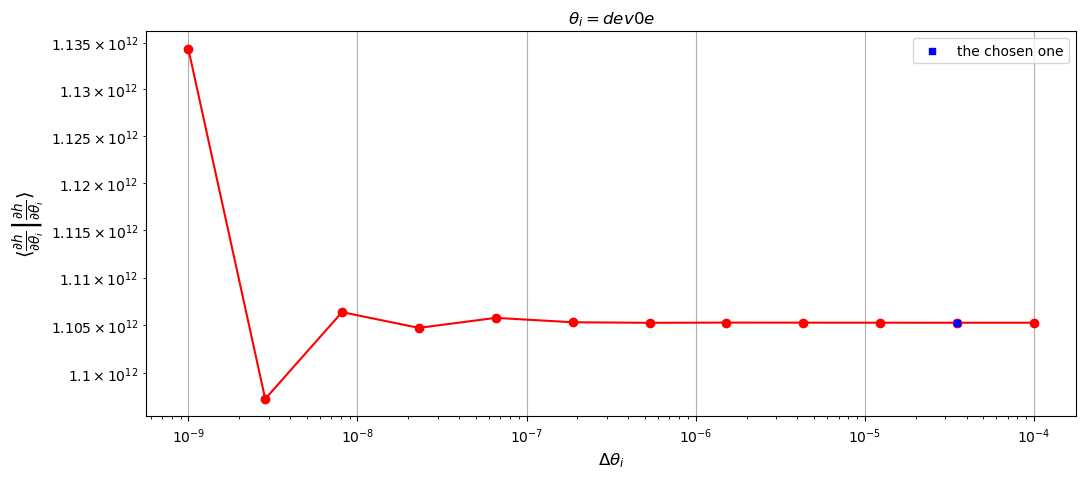

stable deltas: {'m1': 35.11191734215131, 'm2': 0.0003511191734215131, 'a': 2.9845129740828652e-05, 'p0': 8.629927176094463e-05, 'e0': 5.5478103274893e-06, 'qS': 0.00339980115994862, 'phiS': 0.004328761281083062, 'Phi_phi0': 0.0, 'Phi_r0': 0.0, 'dev0p': 3.511191734215135e-05, 'dev0e': 3.511191734215135e-05}
Time taken to compute stable deltas is 136.11531949043274 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 11.935056924819946 seconds


In [19]:
#initialize the 0PA (approximate) model
evolve_1PA = False 
evolve_primary = False
evolve_2PA = False #for approximate model
add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}


param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

param_dict = {
    'm1': m1,
    'm2': m2,
    'a': a,
    'p0': p0,
    'e0': e0,
    'xI0': xI0,
    'dist': dist,
    'qS': qS,
    'phiS': phiS,
    'qK': qK,
    'phiK': phiK,
    'Phi_phi0': Phi_phi0,
    'Phi_theta0': Phi_theta0,
    'Phi_r0': Phi_r0
}
der_order = 8
Ndelta = 12

Fisher = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_param_args,
            live_dangerously = False, stability_plot = True,der_order = der_order, Ndelta = Ndelta,
            )


In [20]:
def logmasstransform(Fisher, m1, index_of_m1 = 0):    
    J = np.eye(len(Fisher))
    J[index_of_m1,index_of_m1] = m1
    
    return J.T@Fisher@J

In [21]:
Fisher[-1].shape

(11, 11)

In [22]:
fisher_=Fisher[-1].copy()
fisher_
# sef.deltas["Phi_phi0"] = 1e-5
# sef.deltas["Phi_r0"] = 1e-5
sef.deltas

{'m1': 35.11191734215131,
 'm2': 0.0003511191734215131,
 'a': 2.9845129740828652e-05,
 'p0': 8.629927176094463e-05,
 'e0': 5.5478103274893e-06,
 'qS': 0.00339980115994862,
 'phiS': 0.004328761281083062,
 'Phi_phi0': 0.0,
 'Phi_r0': 0.0,
 'dev0p': 3.511191734215135e-05,
 'dev0e': 3.511191734215135e-05}

In [23]:
#in this code cell, we are transfroming fisher for numerical stability and will remove parameters that are causing problem

print("Transforming to log-mass")
Fisher_transform = logmasstransform(fisher_, m1)
print("Checking log-mass Fisher positive-definiteness...")
check_flag = True
rows_to_remove = []
for j in range(len(param_names)):
    if param_names[j] in []:#'dist','qS','phiS','qK','phiK','Phi_phi0','Phi_r0']:
            rows_to_remove.append(j)

rows_to_remove = np.array(rows_to_remove)
    
if len(rows_to_remove) > 0:
    Fisher_transformed = np.delete(np.delete(Fisher_transform,rows_to_remove,axis=0),rows_to_remove,axis=1)
    #Fisher = np.delete(np.delete(Fisher,rows_to_remove,axis=0),rows_to_remove,axis=1)

if (np.linalg.eigvals(Fisher_transform) < 0.0).any():
    check_flag = False
    print('positive definiteness failed for: ', i)
        
if check_flag:
    print("positive-definiteness check passed!")
pd.DataFrame(Fisher_transform)

Transforming to log-mass
Checking log-mass Fisher positive-definiteness...
positive-definiteness check passed!


,0,1,2,3,4,5,6,7,8,9,10
0,1.058115e+15,-1.277335e+13,1.000501e+14,2.270233e+14,8.799103e+14,-3.924425e+09,1.809213e+10,-4.742626e+09,-4.399971e+09,-9.392564e+13,-3.381972e+13
1,-1.277335e+13,1.623589e+11,-1.335626e+12,-2.760920e+12,-1.032939e+13,4.290868e+07,-1.978007e+08,5.185212e+07,4.487985e+07,1.202018e+12,4.217146e+11
2,1.000501e+14,-1.335626e+12,1.357017e+13,2.212892e+13,7.879448e+13,-3.483267e+08,1.606309e+09,-4.212929e+08,-2.326555e+08,-9.994088e+12,-3.363308e+12
3,2.270233e+14,-2.760920e+12,2.212892e+13,4.881577e+13,1.880876e+14,-8.384813e+08,3.865591e+09,-1.013352e+09,-9.143045e+08,-2.032924e+13,-7.282504e+12
4,8.799103e+14,-1.032939e+13,7.879448e+13,1.880876e+14,7.422532e+14,-3.430734e+09,1.581665e+10,-4.146112e+09,-3.957773e+09,-7.567091e+13,-2.763278e+13
5,-3.924425e+09,4.290868e+07,-3.483267e+08,-8.384813e+08,-3.430734e+09,2.227926e+04,-9.299389e+04,2.437902e+04,2.242961e+04,3.129545e+08,1.161727e+08
6,1.809213e+10,-1.978007e+08,1.606309e+09,3.865591e+09,1.581665e+10,-9.299389e+04,4.301600e+05,-1.124319e+05,-1.033960e+05,-1.442671e+09,-5.355370e+08
7,-4.742626e+09,5.185212e+07,-4.212929e+08,-1.013352e+09,-4.146112e+09,2.437902e+04,-1.124319e+05,2.947794e+04,2.709703e+04,3.781915e+08,1.403822e+08
8,-4.399971e+09,4.487985e+07,-2.326555e+08,-9.143045e+08,-3.957773e+09,2.242961e+04,-1.033960e+05,2.709703e+04,3.454446e+04,3.225270e+08,1.263199e+08
9,-9.392564e+13,1.202018e+12,-9.994088e+12,-2.032924e+13,-7.567091e+13,3.129545e+08,-1.442671e+09,3.781915e+08,3.225270e+08,8.908979e+12,3.112262e+12


In [24]:
delats=sef.deltas
param_name = sef.param_names

In [25]:
parameters = {}
for i in range(len(param_names_com)):
    parameters[param_names_com[i]] = pars_list_com[i]


order = 8 #order of finite-difference derivative
kind = "central" #kind of finite-difference derivative
parameters

{'m1': 1000000.0,
 'm2': 10,
 'a': 0.85,
 'p0': 7.0,
 'e0': 0.45,
 'xI0': 1.0,
 'dist': 0.4,
 'qS': 0.7853981633974483,
 'phiS': 1.0,
 'qK': 1,
 'phiK': 1.0471975511965976,
 'Phi_phi0': 0.9,
 'Phi_theta0': 0.5,
 'Phi_r0': 0.4,
 'chi2': 0.0,
 'evolve_1PA': False,
 'evolve_primary': False,
 'evolve_2PA': False,
 'deviation_included': True,
 'dev0p': 0.0,
 'dev0e': 0.0,
 'dev1p': 0.0,
 'dev1e': 0.0,
 'dev2p': 0.0,
 'dev2e': 0.0}

In [26]:
# del sef
sef.wave_params_list

[1000000.0,
 10,
 0.85,
 7.0,
 0.45,
 1.0,
 0.4,
 0.7853981633974483,
 1.0,
 1,
 1.0471975511965976,
 0.9,
 0.5,
 0.4,
 0.0,
 False,
 False,
 False,
 True,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0]

In [27]:
sef.waveform_derivative_kwargs

{'parameters': {'m1': 1000000.0,
  'm2': 10,
  'a': 0.85,
  'p0': 7.0,
  'e0': 0.45,
  'xI0': 1.0,
  'dist': 0.4,
  'qS': 0.7853981633974483,
  'phiS': 1.0,
  'qK': 1,
  'phiK': 1.0471975511965976,
  'Phi_phi0': 0.9,
  'Phi_theta0': 0.5,
  'Phi_r0': 0.4,
  'chi2': 0.0,
  'evolve_1PA': False,
  'evolve_primary': False,
  'evolve_2PA': False,
  'deviation_included': True,
  'dev0p': 0.0,
  'dev0e': 0.0,
  'dev1p': 0.0,
  'dev1e': 0.0,
  'dev2p': 0.0,
  'dev2e': 0.0},
 'order': 8,
 'dt': 10.0,
 'T': 0.5}

In [28]:
print(f"Calculating Cutler-Vallisneri Biases")
removed_params = []
print(f'calculating derivatives at {param_names}...')
#Fisher = np.zeros((sef.npar,sef.npar), dtype=np.float64)
dtv = []

for k in range(sef.npar):
        temp=sef.derivative(*sef.wave_params_list,
                             param_to_vary=sef.param_names[k],
                               delta=sef.deltas[sef.param_names[k]],
                               kind=kind, **sef.waveform_derivative_kwargs,use_gpu=use_gpu)
        print(temp)
        print("\n",temp.shape)
        print(f"calculting derivative for {sef.param_names[k]}\n")
        dtv_=np.vstack([temp.real,temp.imag])
        print(dtv_)
        dtv.append(dtv_)
        

print("Finished derivatives")
if sef.use_gpu:
        dtv = cp.asnumpy(cp.asarray(dtv)) #h5py only stores numpy
          
#Jacobian transform to log-masses
for k in range(sef.npar):
    if sef.param_names[k] == 'm1':
        dtv[k] *= m1 #to obtain \partial_{log m1}h

Calculating Cutler-Vallisneri Biases
calculating derivatives at ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0', 'dev0p', 'dev0e']...
[ 1.52144372e-32+8.46352650e-33j  2.00209342e-28-1.57397815e-28j
  4.46096967e-28-1.62977868e-28j ... -1.64040376e-22-1.16470978e-22j
 -1.42749573e-22-1.53639210e-22j -1.12309778e-22-1.87809463e-22j]

 (1577908,)
calculting derivative for m1

[[ 1.52144372e-32  2.00209342e-28  4.46096967e-28 ... -1.64040376e-22
  -1.42749573e-22 -1.12309778e-22]
 [ 8.46352650e-33 -1.57397815e-28 -1.62977868e-28 ... -1.16470978e-22
  -1.53639210e-22 -1.87809463e-22]]
[1.52144402e-22+8.46352067e-23j 1.16893996e-22+1.23249379e-22j
 7.40808482e-23+1.47146555e-22j ... 2.75947624e-18+2.07195900e-18j
 2.36304689e-18+2.68296316e-18j 1.81786560e-18+3.23098331e-18j]

 (1577908,)
calculting derivative for m2

[[1.52144402e-22 1.16893996e-22 7.40808482e-23 ... 2.75947624e-18
  2.36304689e-18 1.81786560e-18]
 [8.46352067e-23 1.23249379e-22 1.47146555e-22 ... 2.071959

In [29]:
params_truth_in = np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,dev_0_p,dev_0_e])
#params_truth_in_transformed = np.array([np.log(m1), m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,dev_0_p,dev_0_e])

# param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']

params_truth_in_considered = np.array([np.log(m1), m2, a, p0, e0, qS, phiS, Phi_phi0,Phi_r0,dev_0_p,dev_0_e])
#params_truth_in_considered = np.array([np.log(m1), m2, a, p0, e0, dev_0_p, dev_0_e])
print(params_truth_in_considered)
waveform_approx = sef.waveform
waveform_approx

[13.81551056 10.          0.85        7.          0.45        0.78539816
  1.          0.9         0.4         0.          0.        ]


array([[ 7.60729615e-22,  5.84474730e-22,  3.70405516e-22, ...,
         3.36683062e-22,  4.18066122e-22,  4.86047197e-22],
       [-4.23180265e-22, -6.16253894e-22, -7.35740971e-22, ...,
         3.95806346e-22,  3.25204600e-22,  2.35575502e-22]],
      shape=(2, 1577908))

In [30]:
#initializing the 1PA (True GR model in our analysis)
evolve_1PA = True 
evolve_primary = False
evolve_2PA = False #for approximate model
dev_0_p=0.0
dev_0_e=0.0
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
deviation_included=True
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

superkludge_wave = GenerateEMRIWaveform(SuperKludgeWaveform,\
                                    sum_kwargs=sum_kwargs,\
                                    return_list=True,
                                    mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                                    inspiral_kwargs=inspiral_kwargs,
                                    use_gpu=use_gpu)
print(add_args)
waveform_true = superkludge_wave(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, *add_args, dt=dt, T=T)
waveform_true= xp.asarray(waveform_true)

[0.0, True, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


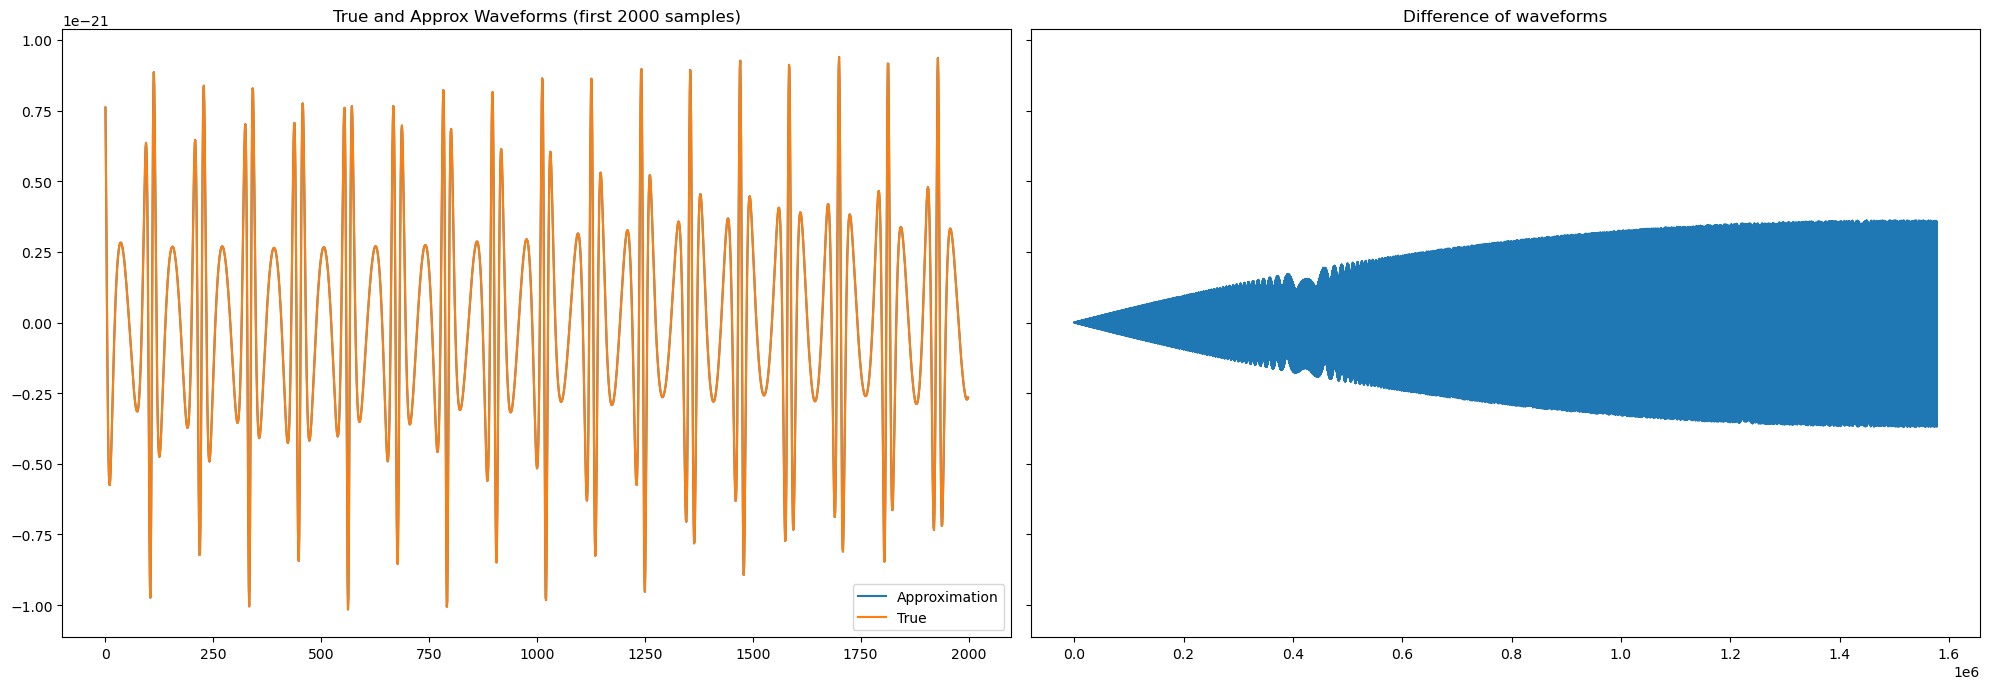

In [31]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7), sharey=True)

# Plot the first 2000 samples of both waveforms
axs[0].plot(waveform_approx[0][0:2000].get(), label="Approximation")
axs[0].plot(waveform_true[0][0:2000].get(), label="True")
axs[0].set_title("True and Approx Waveforms (first 2000 samples)")
axs[0].legend()

# Plot the difference
axs[1].plot(((waveform_true[0] - waveform_approx[0])[0:]).get())
axs[1].set_title("Difference of waveforms")

plt.tight_layout()

In [32]:
biased_params = cutlervallis(waveform_truth=waveform_true, waveform_approx=waveform_approx,
                                 Fisher_truth=Fisher_transform, partial_approx=dtv,
                                 params_truth=params_truth_in_considered, PSD_func = sef.PSD_funcs, dt = dt,
                                  use_gpu=use_gpu)
print(biased_params)

if use_gpu:
        biased_params = cp.asnumpy(cp.asarray(biased_params))

#prior box on chi2
# if 'chi2' not in removed_params:
#     index_chi2 = np.where(param_names == 'chi2')
        
#     if biased_params[index_chi2] > 1.0:
#         biased_params[index_chi2] = 1.0
#     elif biased_params[index_chi2] < -1.0:
#         biased_params[index_chi2] = -1.0

#prior box on cyclic parameters (phases and such)
cyclic_priors = {'qS' : np.pi, 'phiS' : 2 * np.pi, 'qK' : np.pi, 'phiK' : 2 * np.pi, 'Phi_phi0' : 2 * np.pi, 'Phi_r0' : 2 * np.pi}
param_names_in = np.array(param_names)
for param in list(cyclic_priors.keys()):
    if param not in removed_params:
        print(f"modulo {cyclic_priors[param]} for param {param}")
            
        index = np.where(param_names_in == param) 
        biased_params[index] %= cyclic_priors[param]


print('biased params: ', biased_params)

#calculate the sigma contour as the Mahalanobis distance between the true and biased params (https://en.wikipedia.org/wiki/Mahalanobis_distance):
    
sigma_contour = np.sqrt((biased_params - params_truth_in_considered)@Fisher_transform@(biased_params - params_truth_in_considered))
sigma_contour /= np.sqrt(len(params_truth_in_considered)) #scaled Mahalonobis distance for dimensional generality
    
print('sigma contours: ', sigma_contour)

delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 0:  -51582.987387499255
delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 1:  553.8681704200134
delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 2:  -2891.636571550117
delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 3:  -10747.228512141506
delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 4:  -45297.794567294404
delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 5:  1.4501346619832516
delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 6:  0.0545418216615465
delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 7:  0.2465515722575853
delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 8:  0.30023720263031467
delta_wave.shape, partial

In [33]:
print(sigma_contour)

0.01231075812421254


In [34]:
biased_params

array([1.38155114e+01, 9.99914953e+00, 8.50000496e-01, 6.99999703e+00,
       4.49999789e-01, 7.86109696e-01, 1.00077693e+00, 9.02375245e-01,
       3.99998806e-01, 8.57727484e-05, 8.61622960e-05])

In [35]:
params_truth_in_considered

array([13.81551056, 10.        ,  0.85      ,  7.        ,  0.45      ,
        0.78539816,  1.        ,  0.9       ,  0.4       ,  0.        ,
        0.        ])

# plot ig

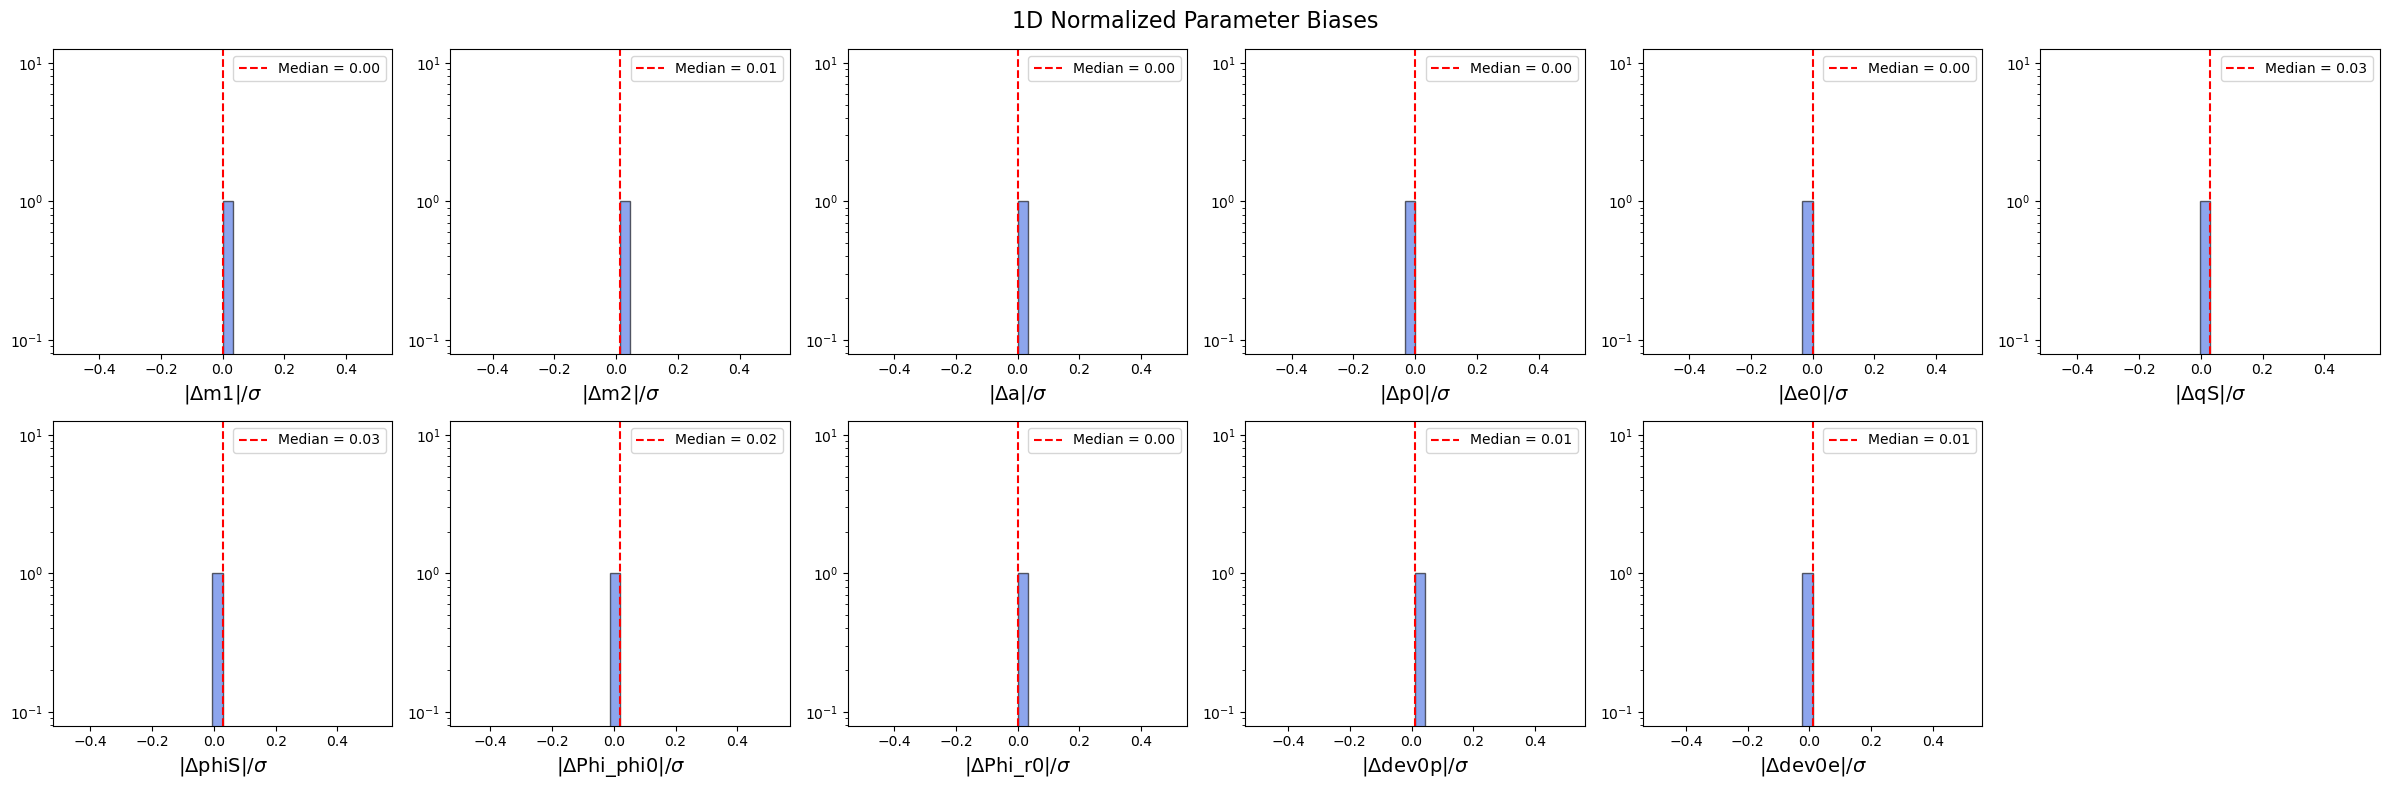

In [36]:
#used gpt (boring part)

# === PARAMETERS ===
param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']


params_truth_in_considered = np.array([
    np.log(m1), m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0, dev_0_p, dev_0_e
])
truevals_i = params_truth_in_considered

Fisher_transformed = Fisher_transform.copy()

# === REMOVE PARAMETERS IF SPECIFIED ===
rows_to_remove = [i for i, name in enumerate(param_names) if name in removed_params]
rows_to_remove = np.array(rows_to_remove)

if len(rows_to_remove) > 0:
    Fisher_transformed = np.delete(Fisher_transformed, rows_to_remove, axis=0)
    Fisher_transformed = np.delete(Fisher_transformed, rows_to_remove, axis=1)
   # param_names_plot = np.delete(param_names_plot, rows_to_remove, axis=0)
    truevals_i = np.delete(truevals_i, rows_to_remove, axis=0)

# === COMPUTE SIGMAS ===
covariance = np.linalg.inv(Fisher_transformed)
sigmas_params = np.sqrt(np.diag(covariance))

# === COMPUTE NORMALIZED BIASES ===
sigmabias_1D = np.abs(biased_params - truevals_i) / sigmas_params

# === PLOT ===
n_params = len(param_names)
ncols = int(np.ceil(n_params / 2))

fig, axs = plt.subplots(2, ncols, figsize=(4 * ncols, 8))
axs = axs.flatten()

for i, name in enumerate(param_names):
    axs[i].hist(sigmabias_1D[i], bins=30, histtype='stepfilled',
                color='royalblue', alpha=0.6, edgecolor='k')
    axs[i].set_xlabel(r"$|\Delta $" + rf"{name}" + r"$|/\sigma$", fontsize=14)
    axs[i].set_yscale('log')
    axs[i].axvline(np.median(sigmabias_1D[i]), color='r', linestyle='--',
                   label=f"Median = {np.median(sigmabias_1D[i]):.2f}")
    axs[i].legend(fontsize=10)

# Hide any unused subplots
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.suptitle("1D Normalized Parameter Biases", fontsize=16)
plt.show()



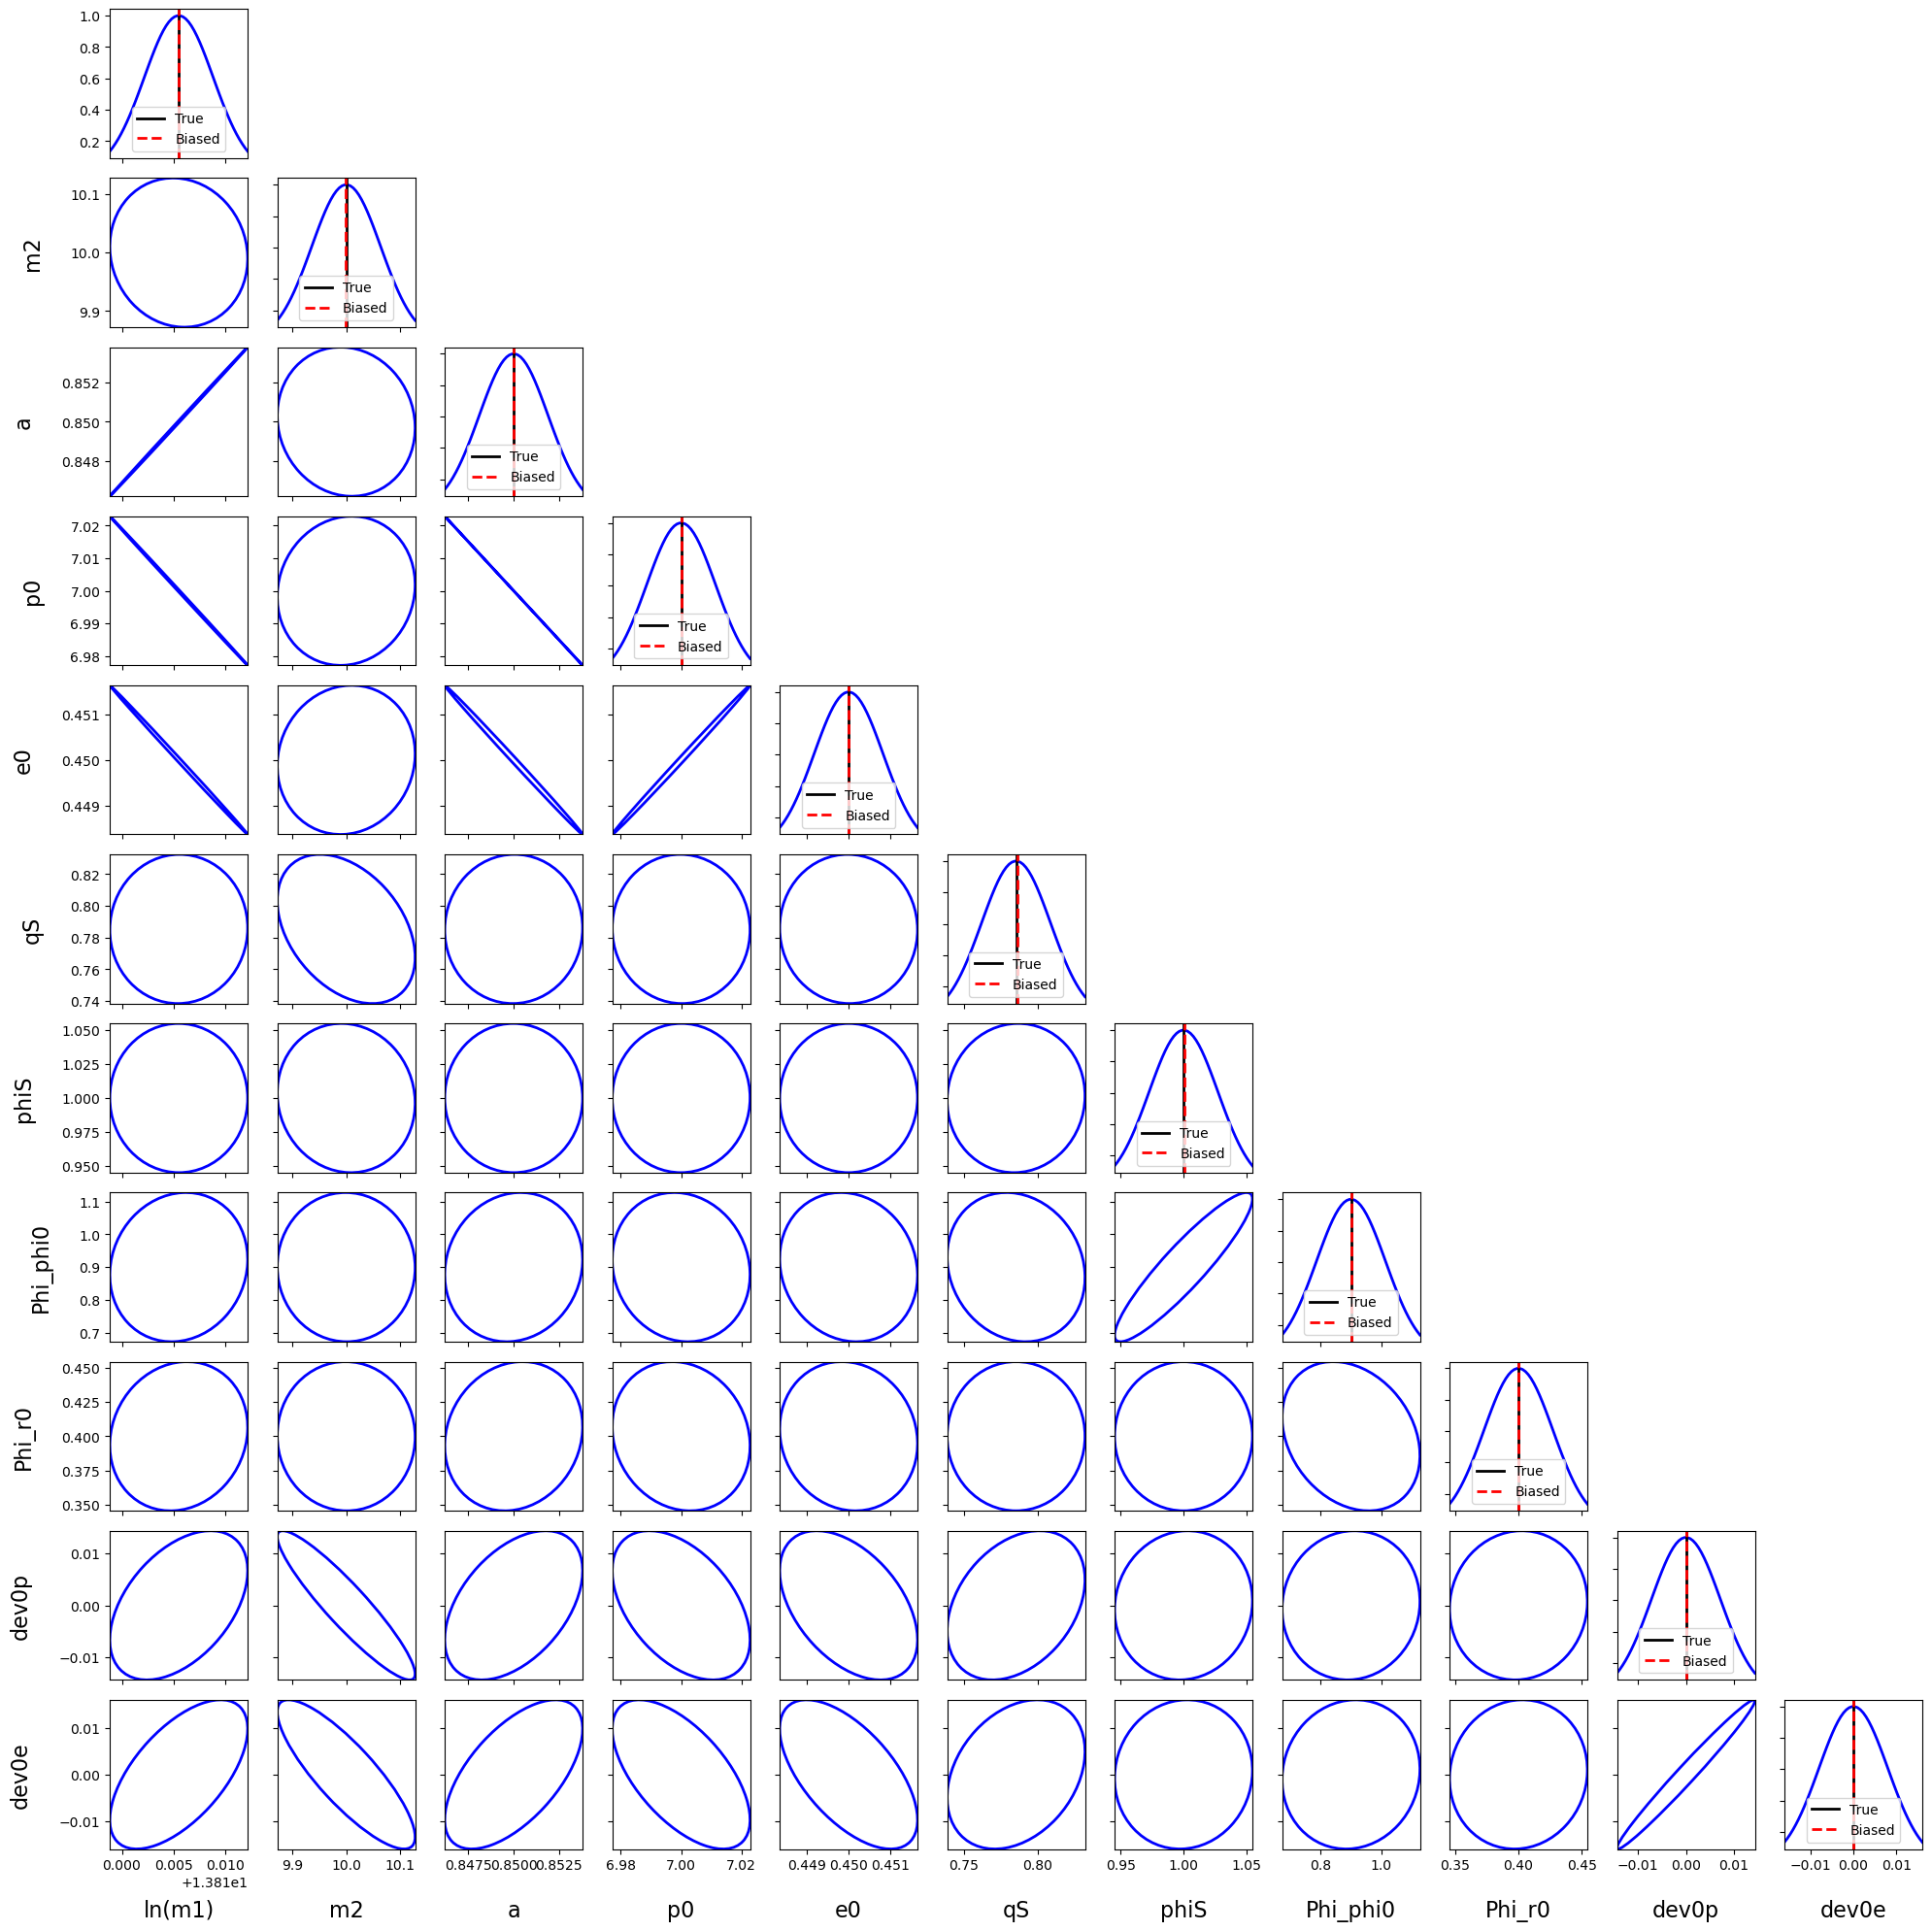

In [37]:
from stableemrifisher.plot import CovEllipsePlot
# pars_list = [m1, m2, p0, e0, dist,qS,phiS,Phi_phi0,Phi_r0,chi2]
# param_names = ['m1','m2','p0','e0','dist','qS','phiS','Phi_phi0','Phi_r0','chi2']
pars_list = params_truth_in_considered
# param_names_plot = [
#     r'$\log{m_1}$', r'$m_2$', r'$a$', r'$p_0$', r'$e_0$',
#     r'$\phi_S$', r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$',
#     r'dev0_p', r'dev0_e'
# ]
param_names = ['ln(m1)','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']

wave_params = {}
for i in range(len(pars_list)):
    wave_params[param_names[i]] = params_truth_in_considered[i]

ellipse_kwargs = dict(facecolor='None', edgecolor='b', lw=2)
line_kwargs = dict(lw=2, color='b')

fig, axs = plt.subplots(len(covariance),len(covariance), figsize=(20,20))
fig, axs = CovEllipsePlot(covariance, wave_params=wave_params, param_names=param_names, fig=fig, axs=axs, ellipse_kwargs=ellipse_kwargs, line_kwargs=line_kwargs)
# === ADD TRUE AND BIASED PARAMETER LINES ===
for i in range(len(param_names)):
    # Diagonal subplot (1D)
    ax = axs[i, i]
    ax.axvline(params_truth_in_considered[i], color='k', linestyle='-', lw=2, label='True')
    ax.axvline(biased_params[i], color='r', linestyle='--', lw=2, label='Biased')
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


In [38]:
biased_params

array([1.38155114e+01, 9.99914953e+00, 8.50000496e-01, 6.99999703e+00,
       4.49999789e-01, 7.86109696e-01, 1.00077693e+00, 9.02375245e-01,
       3.99998806e-01, 8.57727484e-05, 8.61622960e-05])

In [39]:
evolve_1PA = False 
evolve_primary = False
evolve_2PA = False #for approximate model
dev_0_p=biased_params[9]
dev_0_e=biased_params[10]
# param_names = ['ln(m1)','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']

dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
deviation_included=True
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

pars_list = [np.exp(biased_params[0]), biased_params[1], biased_params[2], biased_params[3], \
             biased_params[4], xI0, dist, biased_params[5], biased_params[6], qK, phiK, biased_params[7], Phi_theta0,\
               biased_params[8]]

# superkludge_wave_biased = GenerateEMRIWaveform(SuperKludgeWaveform,\
#                                     sum_kwargs=sum_kwargs,\
#                                     return_list=True,
#                                     mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
#                                     inspiral_kwargs=inspiral_kwargs,
#                                     use_gpu=use_gpu)

waveform_biased = superkludge_wave(*pars_list, *add_args, dt=dt, T=T)


In [40]:
deviation=params_truth_in_considered-biased_params
print("Higher",biased_params)
print("\nTrue",params_truth_in_considered)
print("\nlower",params_truth_in_considered+deviation)

Higher [1.38155114e+01 9.99914953e+00 8.50000496e-01 6.99999703e+00
 4.49999789e-01 7.86109696e-01 1.00077693e+00 9.02375245e-01
 3.99998806e-01 8.57727484e-05 8.61622960e-05]

True [13.81551056 10.          0.85        7.          0.45        0.78539816
  1.          0.9         0.4         0.          0.        ]

lower [ 1.38155097e+01  1.00008505e+01  8.49999504e-01  7.00000297e+00
  4.50000211e-01  7.84686631e-01  9.99223069e-01  8.97624755e-01
  4.00001194e-01 -8.57727484e-05 -8.61622960e-05]


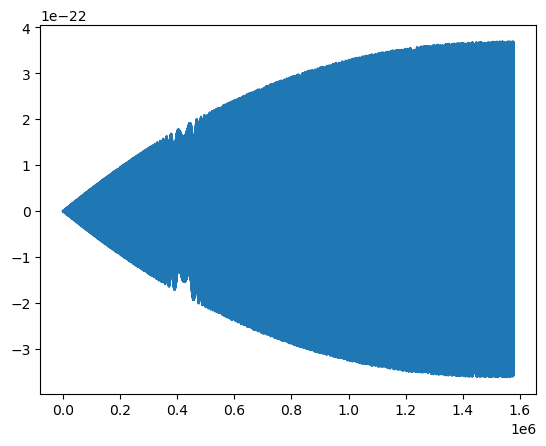

In [47]:
plt.plot((waveform_approx-waveform_true)[0].get())


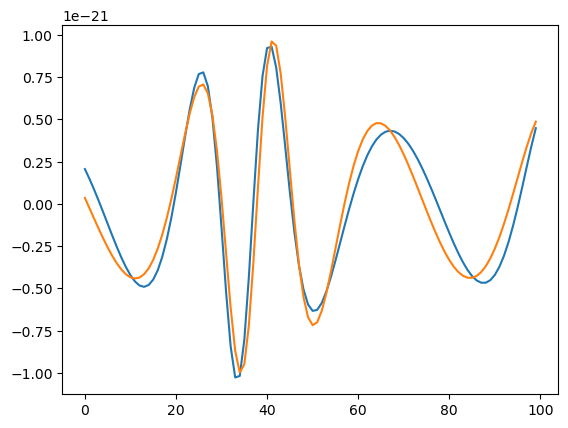

In [42]:
plt.plot((waveform_true)[0][-100:].get())
plt.plot((waveform_biased)[0][-100:].get())

In [43]:
PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
                noise_PSD=get_sensitivity,
                noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                channels=["A","E"])
diff_inner=inner_product(waveform_biased,waveform_true,PSD,dt,use_gpu=use_gpu)
norm_true=np.sqrt(inner_product(waveform_true,waveform_true,PSD,dt,use_gpu=use_gpu))
norm_biased=np.sqrt(inner_product(waveform_biased,waveform_biased,PSD,dt,use_gpu=use_gpu))
diff_inner/((norm_true)*norm_biased)


np.float64(0.9792279953183198)

In [44]:
evolve_1PA = False 
evolve_primary = False
evolve_2PA = False #for approximate model
deviation_included=True
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0

deviation=biased_params-params_truth_in_considered

PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
                noise_PSD=get_sensitivity,
                noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                channels=["A","E"])

norm_true=np.sqrt(inner_product(waveform_true,waveform_true,PSD,dt,use_gpu=use_gpu))
delta = np.linspace(-1,1,500)
save_inner=[]
for i in range(len(delta)):
    biased = params_truth_in_considered + delta[i] * deviation
    dev_0_p= biased[9]
    dev_0_e= biased[10]
    add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
    add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,\
                    "deviation_included":deviation_included,"dev0p":dev_0_p,
        "dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

    pars_list = [np.exp(biased[0]), biased[1], biased[2], biased[3], \
             biased[4], xI0, dist, biased[5], biased[6], qK, phiK, biased[7], Phi_theta0,\
               biased[8]]
    waveform_considered = superkludge_wave(*pars_list, *add_args, dt=dt, T=T,use_gpu=use_gpu)
    diff_inner=inner_product(waveform_considered,waveform_true,PSD,dt,use_gpu=use_gpu)
    norm_biased=np.sqrt(inner_product(waveform_considered,waveform_considered,PSD,dt,use_gpu=use_gpu))
    mismatch=diff_inner/((norm_true)*norm_biased)
   #print(mismatch)
    save_inner.append(mismatch)


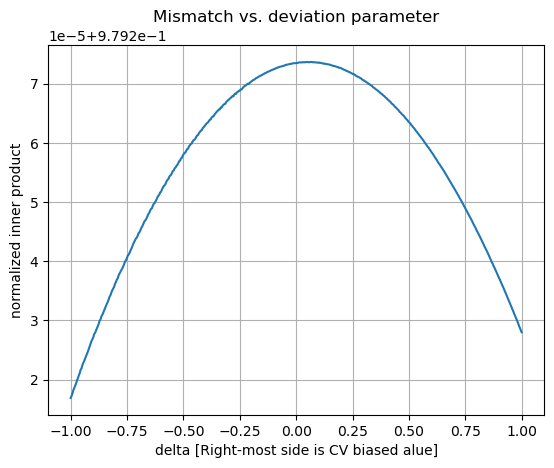

In [45]:
plt.plot(delta,save_inner)
plt.xlabel("delta [Right-most side is CV biased alue]")
plt.ylabel("normalized inner product")
plt.title("Mismatch vs. deviation parameter")
plt.grid(True)

In [46]:
print(np.max(save_inner))
delta[np.argmax(save_inner)]
#0.8587424254524265

0.979273651261433


np.float64(0.05010020040080154)

# ..
1. select mode to reduce noise